In [120]:
import numpy as np
import matplotlib.pyplot as plt

from numpy import pi as PI
from scipy.special import hankel1 as H

Define Relevant Constants and Parameters

In [136]:
V0 = 1 # eV
VF = 906091185689731.9 # nm/s
a = 0.24595 #nm
nb = 7
b = nb*a #nm separation
hop = -2.8 #eV
Hbar = 6.582119569*1e-16 # eV * s

Define Valley

In [122]:
k0 = (4 * PI)/(3 * np.sqrt(3) * a)

K = np.array([-k0, 0])
KP = np.array([k0, 0])

# Make more sophisticated when introducing other valleys
def valIndex(Kvec):
  xi = 0
  if np.sign(Kvec[0]) == -1:
    xi = -1
  elif np.sign(Kvec[0]) == 1:
    xi = 1

  return xi

Location of Points

In [ ]:
# Origin is inbetween defects
R1 = np.array([-b, 0])
R2 = np.array([b, 0])

D12 = R1 - R2

Define Green's Function Matrices

In [124]:
#g is g12 is g(r1 - r2)
# Scalar w energy. 2 component vector K for valley vector
def g(w, K):

  xi = valIndex(K)
  pf = -(w/(2 * VF * Hbar)**2) * np.exp(1j * np.dot(K, D12))
  frac = (w * np.linalg.norm(D12))/(VF*Hbar)

  AA = 1j * H(0, frac) # same as BB for this one
  AB = -xi * H(1, frac) # same as BA for this one

  return pf * np.array([AA, AB, AB, AA])

def gt(w, K):

  xi = valIndex(K)
  pf = -(w/(2 * VF * Hbar)**2) * np.exp(-1j * np.dot(K, D12))
  frac = (w * np.linalg.norm(D12))/(VF*Hbar)

  AA = 1j * H(0, frac) # same as BB for this one
  AB = xi * H(1, frac) # same as BA for this one

  return pf * np.array([AA, AB, AB, AA])

  ############################################

  #gr1 is alpha
  # Scalar w energy. 2 component vector K for valley vector. 2 component vector R position
def alpha(w, K, R):

  D1R = R1 - R

  theta = np.arctan2(D1R[1], D1R[0])

  xi = valIndex(K)
  pf = -(w/(2 * VF * Hbar)**2) * np.exp(-1j * np.dot(K, D1R))
  frac = (w * np.linalg.norm(D1R))/(VF*Hbar)

  AA = 1j * H(0, frac)
  AB = xi * H(1, frac) * np.exp(1j * xi * theta)
  BA = AB * np.exp(-2j * xi * theta) # save one computation

  return pf * np.array([AA, AB, BA, AA])

def alphat(w, K, R):

    D1R = R1 - R

    theta = np.arctan2(D1R[1], D1R[0])

    xi = valIndex(K)
    pf = -(w/(2 * VF * Hbar)**2) * np.exp(1j * np.dot(K, D1R))
    frac = (w * np.linalg.norm(D1R))/(VF*Hbar)

    AA = 1j * H(0, frac)
    AB = -xi * H(1, frac) * np.exp(1j * xi * theta)
    BA = AB * np.exp(-2j * xi * theta) # save one computation

    return pf * np.array([AA, AB, BA, AA])

############################################

# gr2 is beta
# Scalar w energy. 2 component vector K for valley vector. 2 component vector R position
def beta(w, K, R):

  D2R = R2 - R

  theta = np.arctan2(D2R[1], D2R[0])

  xi = valIndex(K)
  pf = -(w/(2 * VF * Hbar)**2) * np.exp(-1j * np.dot(K, D2R))
  frac = (w * np.linalg.norm(D2R))/(VF*Hbar)

  AA = 1j * H(0, frac)
  AB = xi * H(1, frac) * np.exp(1j * xi * theta)
  BA = AB * np.exp(-2j * xi * theta) # save one computation

  return pf * np.array([AA, AB, BA, AA])

def betat(w, K, R):

    D2R = R2 - R

    theta = np.arctan2(D2R[1], D2R[0])

    xi = valIndex(K)
    pf = -(w/(2 * VF * Hbar)**2) * np.exp(1j * np.dot(K, D2R))
    frac = (w * np.linalg.norm(D2R))/(VF*Hbar)

    AA = 1j * H(0, frac)
    AB = -xi * H(1, frac) * np.exp(1j * xi * theta)
    BA = AB * np.exp(-2j * xi * theta) # save one computation

    return pf * np.array([AA, AB, BA, AA])

In [125]:
test = np.array([["AA", "AB"], ["BA", "BB"]])
print(test)

[['AA' 'AB']
 ['BA' 'BB']]


In [126]:
test[1][0] # just be aware of this convention is flipped from how I am writing it

np.str_('BA')

Additional Functions

In [127]:
print(gt(0.2, K)[0])

(-0.08420636872332991+0.05652402110348521j)


In [128]:
# On site unperturbed greens function
def g0(w):
  return w/(np.sqrt(3)*PI*hop**2) * np.log(w ** 2/(np.sqrt(3)*PI*hop ** 2)) - 1j * np.abs(w)/(np.sqrt(3)*hop ** 2)

def t(w):
  return V0 / (1 - V0 * g0(w))

# Also depends on valley?
def Rf(w, K):
  return 1 / (1 - t(w) ** 2 * g(w, K)[0] * gt(w, K)[0])

LDOS Functions

In [129]:

# Valley Scheme
#          a, at, b, bt, g, gt
#          0, 01, 2, 03, 4, 05
vscheme = [K, KP, K, KP, K, K]
vscheme2 = [KP, K, KP, K, KP, KP]

# First order LDOS for test
def dLDOS1(w, R, vs):
  trace = alphat(w, vs[1], R)[0] * alpha(w, vs[0], R)[0] + alphat(w, vs[1], R)[1] * alpha(w, vs[0], R)[2] + betat(w, vs[3], R)[0]*beta(w, vs[2], R)[0] + betat(w, vs[3], R)[1]*beta(w, vs[2], R)[2]

  return np.imag(Rf(w, K) * t(w) * trace)

# Second Order
def dLDOS2(w, R, vs):
  trace = gt(w, vs[5])[0]*alphat(w, vs[1], R)[0]*beta(w, vs[2], R)[0] + gt(w, vs[5])[0]*alphat(w, vs[1], R)[1]*beta(w, vs[2], R)[2] + g(w, vs[4])[0]*betat(w, vs[3], R)[0]*alpha(w, vs[0], R)[0] + g(w, vs[4])[0]*betat(w, vs[3], R)[1]*alpha(w, vs[0], R)[2]

  return np.imag(Rf(w, K) * t(w) ** 2 * trace)

In [130]:
alphat(0.2, KP, [4, 4])[0]

np.complex128(0.07081342517143213+0.016090277130147494j)

Plotting

In [131]:
x = np.linspace(-6, 6, 1000)
y = np.linspace(-6, 6, 1000)

X, Y = np.meshgrid(x, y)
Z1 = np.zeros_like(X)
Z2 = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Rvec = [X[i, j], Y[i, j]]
        Z1[i, j] = (dLDOS1(0.2, Rvec, vscheme) + dLDOS1(0.2, Rvec, vscheme2)) * (X[i, j] ** 2 + Y[i, j] ** 2)
        Z2[i, j] = (dLDOS2(0.2, Rvec, vscheme) + dLDOS2(0.2, Rvec, vscheme2)) * (X[i, j] ** 2 + Y[i, j] ** 2)

Text(0, 0.5, 'y (nm)')

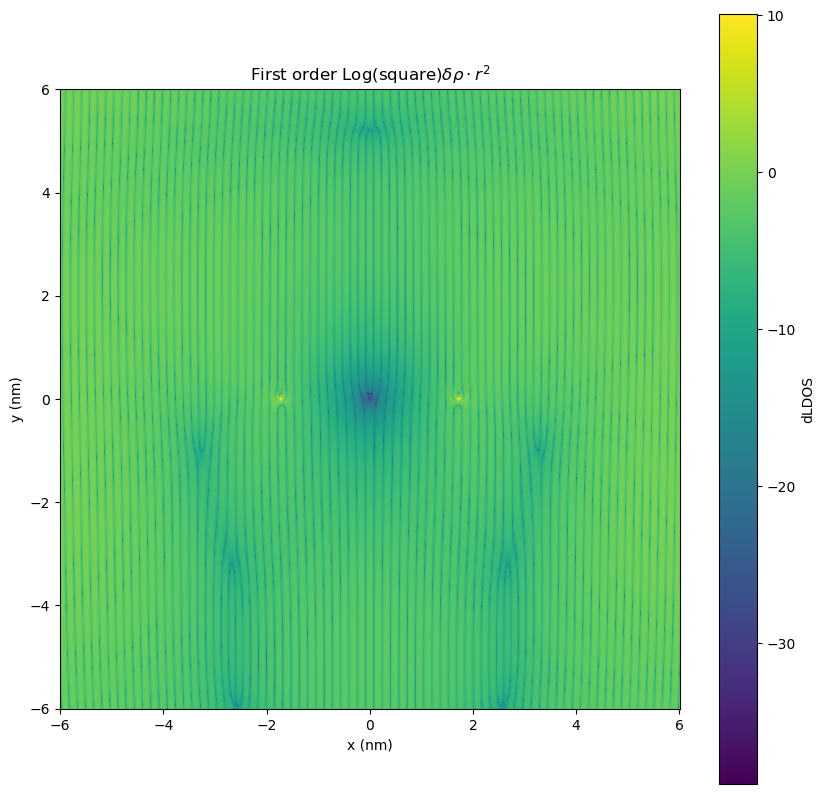

In [132]:
fig1, ax1 = plt.subplots(figsize=(10, 10))

ax1.pcolormesh(X, Y, np.log(Z1**2))
ax1.set_aspect('equal')
pc = plt.pcolormesh(X, Y, np.log(Z1**2), shading='auto', cmap='viridis')
cbar = fig1.colorbar(pc)  # This is the "pcolorbar"
cbar.set_label('dLDOS')
ax1.set_title('First order Log(square)$\\delta \\rho \\cdot r^2$')
ax1.set_xlabel("x (nm)")
ax1.set_ylabel("y (nm)")

Text(0, 0.5, 'y (nm)')

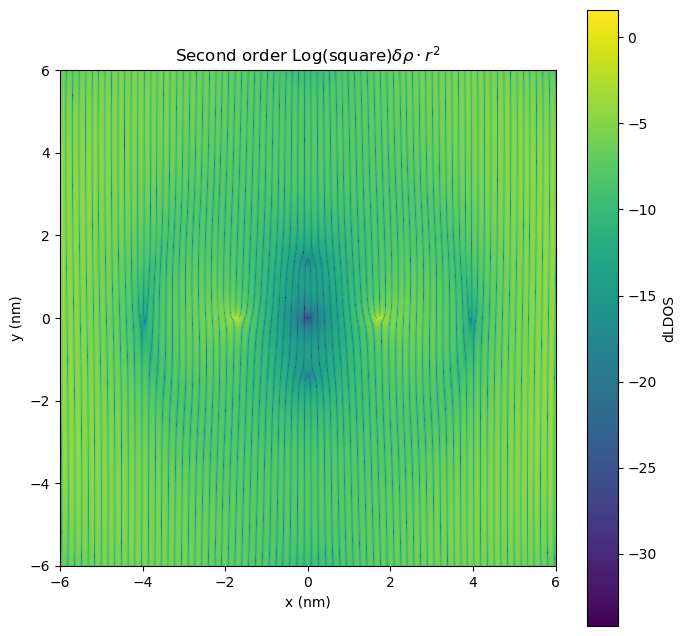

In [133]:
fig2, ax2 = plt.subplots(figsize=(8,8))

ax2.pcolormesh(X, Y, np.log(Z2**2))
ax2.set_aspect('equal')
pc = plt.pcolormesh(X, Y, np.log(Z2**2), shading='auto', cmap='viridis')
cbar = fig2.colorbar(pc)  # This is the "pcolorbar"
cbar.set_label('dLDOS')
ax2.set_title('Second order Log(square)$\\delta \\rho \\cdot r^2$')
ax2.set_xlabel("x (nm)")
ax2.set_ylabel("y (nm)")

Text(0, 0.5, 'y (nm)')

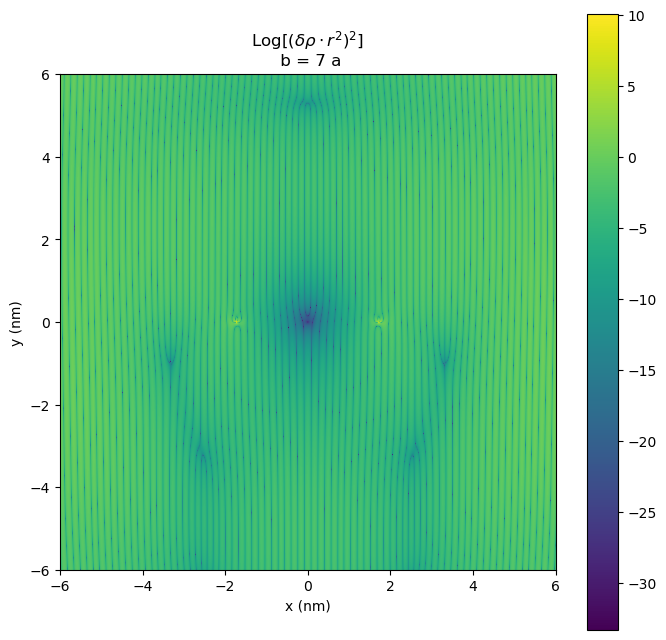

In [144]:
fig3, ax3 = plt.subplots(figsize=(8, 8))

ax3.pcolormesh(X, Y, np.log((Z1 + Z2) ** 2))
ax3.set_aspect('equal')
pc = plt.pcolormesh(X, Y, np.log((Z1 + Z2) ** 2), shading='auto', cmap='viridis')
cbar = fig3.colorbar(pc)  # This is the "pcolorbar"
ax3.set_title('Log$[(\\delta \\rho \\cdot r^2)^2]$' + '\n b = ' + str(nb) + ' a')
ax3.set_xlabel("x (nm)")
ax3.set_ylabel("y (nm)")

In [145]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.
